In [1]:
import uproot
import numpy as np
import awkward as ak
import pandas as pd
import matplotlib.pyplot as plt
import ROOT
import os

In [34]:
Plot_dir = "/eos/user/b/bbapi/www/Analysis_plots/BDT/features_plot/"

In [42]:
Plot_dir_re = "/eos/user/b/bbapi/www/Analysis_plots/BDT/features_plot_reassign_weight/"

In [5]:
dataset_Bkg = uproot.open('merged_bkg_withMass.root')['DiphotonTree'].arrays()

df_bkg = ak.to_dataframe(dataset_Bkg)

In [11]:
dataset_sig = uproot.open('merged_signal.root')['DiphotonTree'].arrays()

df_sig = ak.to_dataframe(dataset_sig)

In [11]:
dataset_bkg_scored = uproot.open('scored_background.root')['DiphotonTree'].arrays()

df_bkg_scored = ak.to_dataframe(dataset_bkg_scored)    

In [3]:
df_bkg_scored.head()

,BDT_score,delphi_bb,delphi_bbgg,delphi_gg,first_jet_B,first_jet_eta,lepeta,leppt,mass_point,n_bJets,pT1_by_mbb,pT1_by_mgg,pT2_by_mbb,pT2_by_mgg,pholead_eta,pholead_mvaID,phosublead_eta,phosublead_mvaID,second_jet_B,second_jet_eta
entry,,,,,,,,,,,,,,,,,,,,
0,0.417167,0.662109,1.807626,2.598127,0.224243,-0.321716,1.462891,31.069300,45,2.0,0.820247,0.408999,0.607428,0.310073,2.105957,0.022522,0.313049,0.871582,0.194489,-1.478271
1,0.240847,0.484863,0.036653,0.565918,0.164551,-1.750488,0.506226,36.641403,20,3.0,0.301315,1.134800,0.191534,0.843487,-0.277222,0.356445,0.554688,0.924805,0.138306,1.191895
2,0.709252,3.067749,3.071917,2.727295,0.538574,-0.439941,-2.283203,35.469872,50,2.0,0.492777,0.600130,0.492774,0.374633,-0.592285,0.856934,-1.358887,0.812988,0.128967,-0.639038
3,0.725521,0.011475,0.530571,3.053223,0.492249,-1.293457,-0.039993,155.404068,25,2.0,1.713979,0.516193,0.760131,0.484012,-2.302246,-0.026917,-2.200684,-0.170288,0.353577,-2.061523
4,0.061949,0.688416,2.078953,1.782941,0.993652,1.003662,0.832520,40.788990,20,2.0,0.357297,0.721175,0.173654,0.555341,1.954590,0.091736,1.680176,0.690430,0.591431,-1.856445


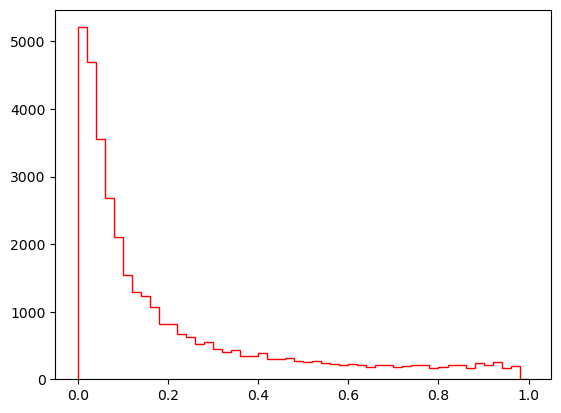

In [12]:
plt.hist(df_bkg_scored['BDT_score'], bins=50, range=(0,1), histtype='step', label='Background', color='red');

In [24]:
selected_bkg = df_bkg_scored[df_bkg_scored['BDT_score'] > 0.9]

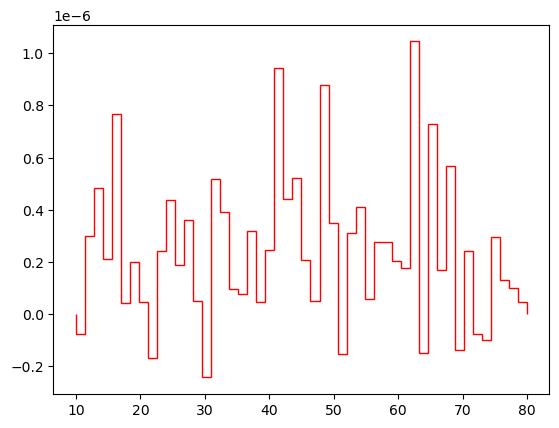

In [25]:
plt.hist(selected_bkg['CMS_hgg_mass'], weights = selected_bkg['weight'], bins=50, range=(10,80), histtype='step', label='Background', color='red');

In [6]:
df_bkg.head()

,HTXS_Higgs_pt,HTXS_Higgs_y,HTXS_njets30,HTXS_stage_0,Njets,charge,dZ,delphi_bb,delphi_bbgg,delphi_gg,...,weight_PS_ISRUp,weight_PileupDown,weight_PileupUp,weight_central,weight_nominal,nweight_LHEScale,phys_wgt,process_id,evt_wgt,mass_point
entry,,,,,,,,,,,,,,,,,,,,,
0,0.0,NaN,0,0.0,2.0,0.0,-0.002258,0.662109,1.807626,2.598127,...,1.099975e-13,1.751640e-13,7.986567e-14,0.882317,-23628.455025,9,-0.000007,5,-0.000601,45
1,0.0,NaN,0,0.0,5.0,0.0,0.003578,0.484863,0.036653,0.565918,...,1.003570e-13,1.751640e-13,7.986567e-14,0.882317,23628.455025,9,0.000007,5,0.000601,20
2,0.0,NaN,0,0.0,3.0,0.0,-0.002396,3.067749,3.071917,2.727295,...,1.997682e-13,1.749075e-13,1.177894e-13,1.181303,-31635.310582,9,-0.000010,5,-0.000805,50
3,0.0,NaN,0,0.0,2.0,0.0,0.000793,0.011475,0.530571,3.053223,...,1.087629e-13,1.004283e-13,6.342140e-14,0.584097,15642.123247,9,0.000005,5,0.000398,25
4,0.0,NaN,0,0.0,2.0,0.0,0.000839,0.688416,2.078953,1.782941,...,3.341664e-13,1.531043e-13,2.789925e-13,1.831180,49039.028715,9,0.000015,5,0.001248,20


In [38]:
for i in range(len(df_bkg.columns)):
    print(i, df_bkg.columns[i])

0 HTXS_Higgs_pt
1 HTXS_Higgs_y
2 HTXS_njets30
3 HTXS_stage_0
4 Njets
5 charge
6 dZ
7 delphi_bb
8 delphi_bbgg
9 delphi_gg
10 diff_first_jet_probb_probbb
11 dipho_pt
12 electron_charge
13 electron_eta
14 electron_mass
15 electron_phi
16 electron_pt
17 eta
18 event
19 first_jet_B
20 first_jet_charge
21 first_jet_eta
22 first_jet_mass
23 first_jet_mass_raw
24 first_jet_phi
25 first_jet_probb
26 first_jet_probbb
27 first_jet_pt
28 first_jet_pt_raw
29 fixedGridRhoAll
30 genWeight
31 lepeta
32 leppt
33 lumi
34 CMS_hgg_mass
35 muon_charge
36 muon_eta
37 muon_mass
38 muon_phi
39 muon_pt
40 nPV
41 n_bJets
42 pT1_by_mbb
43 pT1_by_mgg
44 pT2_by_mbb
45 pT2_by_mgg
46 phi
47 pholead_ScEta
48 pholead_charge
49 pholead_cutBased
50 pholead_ecalPFClusterIso
51 pholead_electronIdx
52 pholead_electronIdxG
53 pholead_electronVeto
54 pholead_energyErr
55 pholead_energyRaw
56 pholead_esEffSigmaRR
57 pholead_esEnergyOverRawE
58 pholead_eta
59 pholead_etaWidth
60 pholead_genPartFlav
61 pholead_genPartIdx
62 pho

In [10]:
for i in range(len(selected_bkg.columns)):
    print(i, selected_bkg.columns[i])

0 BDT_score
1 delphi_bb
2 delphi_bbgg
3 delphi_gg
4 first_jet_B
5 first_jet_eta
6 lepeta
7 leppt
8 mass_point
9 n_bJets
10 pT1_by_mbb
11 pT1_by_mgg
12 pT2_by_mbb
13 pT2_by_mgg
14 pholead_eta
15 pholead_mvaID
16 phosublead_eta
17 phosublead_mvaID
18 second_jet_B
19 second_jet_eta


In [35]:
def plot_feature_distribution_ROOT(feature, df_sig, df_bkg,
                              bins=50,
                              xmin=None,
                              xmax=None):

    # Convert to numpy
    sig_vals = df_sig[feature].to_numpy()
    bkg_vals = df_bkg[feature].to_numpy()

    sig_wgts = df_sig["evt_wgt"].to_numpy()
    bkg_wgts = df_bkg["evt_wgt"].to_numpy()

    # Auto range
    if xmin is None:
        xmin = min(sig_vals.min(), bkg_vals.min())

    if xmax is None:
        xmax = max(sig_vals.max(), bkg_vals.max())

    # Histograms
    h_sig = ROOT.TH1F(
        "h_sig",
        "",
        bins,
        xmin,
        xmax
    )

    h_bkg = ROOT.TH1F(
        "h_bkg",
        "",
        bins,
        xmin,
        xmax
    )

    # Fill histograms
    for val, wgt in zip(sig_vals, sig_wgts):
        h_sig.Fill(val, wgt)

    for val, wgt in zip(bkg_vals, bkg_wgts):
        h_bkg.Fill(val, wgt)

    # Style
    ROOT.gStyle.SetOptStat(0)

    h_sig.SetLineColor(ROOT.kBlue)
    h_sig.SetFillColorAlpha(ROOT.kBlue, 0.35)
    h_sig.SetLineWidth(2)

    h_bkg.SetLineColor(ROOT.kRed)
    h_bkg.SetFillColorAlpha(ROOT.kRed, 0.35)
    h_bkg.SetLineWidth(2)

    # Axis labels
    h_bkg.GetXaxis().SetTitle(feature)
    h_bkg.GetYaxis().SetTitle("Weighted Events")

    # Canvas
    c = ROOT.TCanvas("c", "", 800, 700)
    c.SetLeftMargin(0.15)

    # Draw
    maxy = max(h_sig.GetMaximum(), h_bkg.GetMaximum())
    h_bkg.SetMaximum(maxy * 1.3)

    h_bkg.Draw("HIST")
    h_sig.Draw("HIST SAME")

    # Legend
    leg = ROOT.TLegend(0.65, 0.75, 0.88, 0.88)
    leg.AddEntry(h_sig, "Signal", "f")
    leg.AddEntry(h_bkg, "Background", "f")
    leg.SetBorderSize(0)
    leg.Draw()
    
    os.makedirs("Plots", exist_ok=True)

    # Save
    c.SaveAs(Plot_dir + f"{feature}.png")
    c.SaveAs(Plot_dir + f"{feature}.pdf")

    return c, h_sig, h_bkg

In [21]:
def plot_feature_distribution(feature, df_sig, df_bkg):
    plt.hist(df_bkg[feature], bins=50, alpha=0.5, label='Background', weights=df_bkg.evt_wgt);
    plt.hist(df_sig[feature], bins=50, alpha=0.5, label='Signal', weights=df_sig.evt_wgt);
    plt.xlabel(feature);
    plt.ylabel('Frequency');
    plt.title(f'Distribution of {feature}');
    plt.legend();
    plt.show()

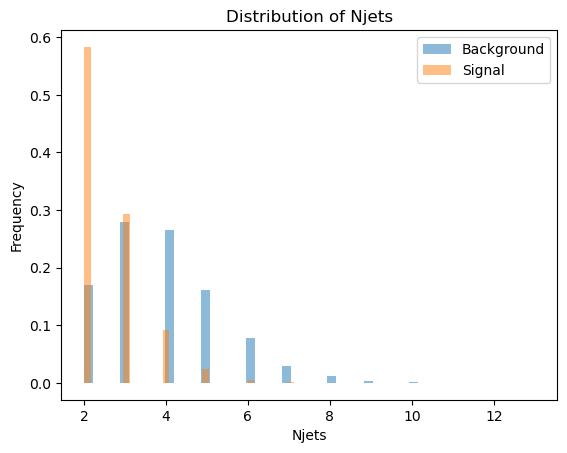

In [17]:
plt.hist(df_bkg.Njets, bins=50, alpha=0.5, label='Background', weights=df_bkg.evt_wgt);
plt.hist(df_sig.Njets, bins=50, alpha=0.5, label='Signal', weights=df_sig.evt_wgt);
plt.xlabel('Njets');
plt.ylabel('Frequency');
plt.title('Distribution of Njets');
plt.legend();
plt.show();

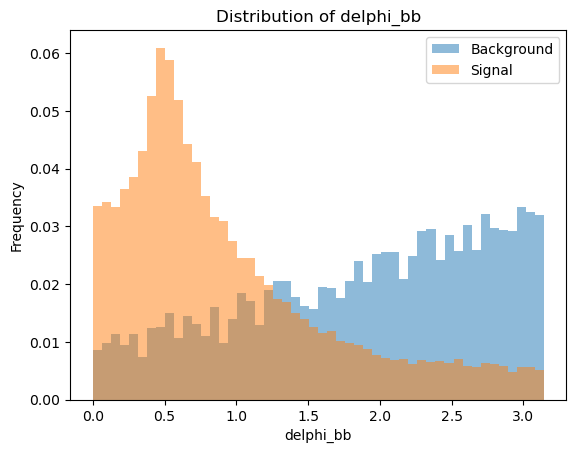

In [18]:
plot_feature_distribution('delphi_bb', df_sig, df_bkg)

In [41]:
plot_feature_distribution_ROOT('delphi_bb', df_sig, df_bkg)
plot_feature_distribution_ROOT('Njets', df_sig, df_bkg)
plot_feature_distribution_ROOT('delphi_gg', df_sig, df_bkg)
plot_feature_distribution_ROOT('delphi_bbgg', df_sig, df_bkg)
plot_feature_distribution_ROOT('pT1_by_mbb', df_sig, df_bkg)
plot_feature_distribution_ROOT('pT2_by_mbb', df_sig, df_bkg)
plot_feature_distribution_ROOT('pT1_by_mgg', df_sig, df_bkg)
plot_feature_distribution_ROOT('pT2_by_mgg', df_sig, df_bkg)
plot_feature_distribution_ROOT('n_bJets', df_sig, df_bkg)
plot_feature_distribution_ROOT('leppt', df_sig, df_bkg)
plot_feature_distribution_ROOT('lepeta', df_sig, df_bkg)
plot_feature_distribution_ROOT("first_jet_eta",  df_sig, df_bkg)
plot_feature_distribution_ROOT("second_jet_eta",  df_sig, df_bkg)
plot_feature_distribution_ROOT("pholead_eta",  df_sig, df_bkg)
plot_feature_distribution_ROOT("phosublead_eta",  df_sig, df_bkg)
plot_feature_distribution_ROOT("first_jet_B",  df_sig, df_bkg)
plot_feature_distribution_ROOT("second_jet_B",  df_sig, df_bkg)
plot_feature_distribution_ROOT("pholead_mvaID",  df_sig, df_bkg)
plot_feature_distribution_ROOT("phosublead_mvaID",  df_sig, df_bkg)

(<cppyy.gbl.TCanvas object at 0x55f7ae185d30>,
 <cppyy.gbl.TH1F object at 0x55f7afab5f20>)

Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/BDT/features_plot/delphi_bb.png has been created
Info in <TCanvas::Print>: pdf file /eos/user/b/bbapi/www/Analysis_plots/BDT/features_plot/delphi_bb.pdf has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/BDT/features_plot/Njets.png has been created
Info in <TCanvas::Print>: pdf file /eos/user/b/bbapi/www/Analysis_plots/BDT/features_plot/Njets.pdf has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/BDT/features_plot/delphi_gg.png has been created
Info in <TCanvas::Print>: pdf file /eos/user/b/bbapi/www/Analysis_plots/BDT/features_plot/delphi_gg.pdf has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/BDT/features_plot/delphi_bbgg.png has been created
Info in <TCanvas::Print>: pdf file /eos/user/b/bbapi/www/Analysis_plots/BDT/features_plot/delphi_bbgg.pdf has been created
Info in <TCanvas::Print>: png file /

In [46]:
len(df_bkg.evt_wgt[df_bkg.evt_wgt<0])/len(df_bkg.evt_wgt)

0.12241604763097126

In [50]:
bkg_sum = df_bkg['evt_wgt'].sum()

# make positive
df_bkg['evt_wgt_re'] = df_bkg['evt_wgt'].apply(
    lambda x: x if x >= 0 else np.abs(x)
)

# sum after abs
bkg_sum_abs = df_bkg['evt_wgt_re'].sum()

# rescale positive weights to preserve original normalization
df_bkg['evt_wgt_re'] = df_bkg['evt_wgt_re'].apply(
    lambda x: x * (bkg_sum / bkg_sum_abs)
)

bkg_sum_re = df_bkg['evt_wgt_re'].sum()

In [51]:
df_bkg['evt_wgt_re']

entry
0        0.000395
1        0.000395
2        0.000528
3        0.000261
4        0.000819
           ...   
35938    0.000109
35939    0.000478
35940    0.000155
35941    0.000061
35942    0.000182
Name: evt_wgt_re, Length: 35943, dtype: float64

In [54]:
def plot_bkg_feature_distribution_ROOT(
    feature,
    df_bkg,
    bins=50,
    xmin=None,
    xmax=None,
    Plot_dir="Plots/"
):

    # Values
    vals = df_bkg[feature].to_numpy()

    # Original weights
    wgts_old = df_bkg["evt_wgt"].to_numpy()

    # Reassigned / positive weights
    wgts_new = df_bkg["evt_wgt_re"].to_numpy()

    # Auto range
    if xmin is None:
        xmin = vals.min()

    if xmax is None:
        xmax = vals.max()

    # Histograms
    h_old = ROOT.TH1F(
        f"h_old_{feature}",
        "",
        bins,
        xmin,
        xmax
    )

    h_new = ROOT.TH1F(
        f"h_new_{feature}",
        "",
        bins,
        xmin,
        xmax
    )

    # Fill histograms
    for val, wgt in zip(vals, wgts_old):
        h_old.Fill(val, wgt)

    for val, wgt in zip(vals, wgts_new):
        h_new.Fill(val, wgt)

    # Style
    ROOT.gStyle.SetOptStat(0)

    # Original weights
    h_old.SetLineColor(ROOT.kRed + 1)
    h_old.SetFillColorAlpha(ROOT.kRed + 1, 0.25)
    h_old.SetLineWidth(2)

    # Reassigned weights
    h_new.SetLineColor(ROOT.kBlue + 1)
    h_new.SetFillColorAlpha(ROOT.kBlue + 1, 0.25)
    h_new.SetLineWidth(2)

    # Axis labels
    h_old.GetXaxis().SetTitle(feature)
    h_old.GetYaxis().SetTitle("Weighted Events")

    # Canvas
    c = ROOT.TCanvas(
        f"c_{feature}",
        "",
        800,
        700
    )

    c.SetLeftMargin(0.15)

    # Draw
    maxy = max(h_old.GetMaximum(), h_new.GetMaximum())
    h_old.SetMaximum(maxy * 1.3)

    h_old.Draw("HIST")
    h_new.Draw("HIST SAME")

    # Legend
    leg = ROOT.TLegend(0.60, 0.75, 0.88, 0.88)

    leg.AddEntry(
        h_old,
        "Original weights",
        "f"
    )

    leg.AddEntry(
        h_new,
        "Reassigned weights",
        "f"
    )

    leg.SetBorderSize(0)
    leg.Draw()

    # Create directory
    os.makedirs(Plot_dir, exist_ok=True)

    # Save
    c.SaveAs(f"{Plot_dir_re}/{feature}_weightComparison.png")
    c.SaveAs(f"{Plot_dir_re}/{feature}_weightComparison.pdf")

    return c, h_old, h_new

In [55]:
plot_bkg_feature_distribution_ROOT('delphi_bb', df_bkg)
plot_bkg_feature_distribution_ROOT('Njets', df_bkg)
plot_bkg_feature_distribution_ROOT('delphi_gg', df_bkg)
plot_bkg_feature_distribution_ROOT('delphi_bbgg', df_bkg)
plot_bkg_feature_distribution_ROOT('pT1_by_mbb', df_bkg)
plot_bkg_feature_distribution_ROOT('pT2_by_mbb', df_bkg)
plot_bkg_feature_distribution_ROOT('pT1_by_mgg', df_bkg)
plot_bkg_feature_distribution_ROOT('pT2_by_mgg', df_bkg)
plot_bkg_feature_distribution_ROOT('n_bJets', df_bkg)
plot_bkg_feature_distribution_ROOT('leppt', df_bkg)
plot_bkg_feature_distribution_ROOT('lepeta', df_bkg)
plot_bkg_feature_distribution_ROOT("first_jet_eta",  df_bkg)
plot_bkg_feature_distribution_ROOT("second_jet_eta",  df_bkg)
plot_bkg_feature_distribution_ROOT("pholead_eta",  df_bkg)
plot_bkg_feature_distribution_ROOT("phosublead_eta",  df_bkg)
plot_bkg_feature_distribution_ROOT("first_jet_B",  df_bkg)
plot_bkg_feature_distribution_ROOT("second_jet_B",  df_bkg)
plot_bkg_feature_distribution_ROOT("pholead_mvaID",  df_bkg)
plot_bkg_feature_distribution_ROOT("phosublead_mvaID",  df_bkg)

(<cppyy.gbl.TCanvas object at 0x55f7af61f3e0>,
 <cppyy.gbl.TH1F object at 0x55f7afb151c0>)

Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/BDT/features_plot_reassign_weight//delphi_bb_weightComparison.png has been created
Info in <TCanvas::Print>: pdf file /eos/user/b/bbapi/www/Analysis_plots/BDT/features_plot_reassign_weight//delphi_bb_weightComparison.pdf has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/BDT/features_plot_reassign_weight//Njets_weightComparison.png has been created
Info in <TCanvas::Print>: pdf file /eos/user/b/bbapi/www/Analysis_plots/BDT/features_plot_reassign_weight//Njets_weightComparison.pdf has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/BDT/features_plot_reassign_weight//delphi_gg_weightComparison.png has been created
Info in <TCanvas::Print>: pdf file /eos/user/b/bbapi/www/Analysis_plots/BDT/features_plot_reassign_weight//delphi_gg_weightComparison.pdf has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/BDT/fe

In [56]:
df_bkg.evt_wgt_re.sum()

1.0

In [57]:
df_bkg.evt_wgt.sum()

1.0

TLS: Unable to use cert+key file /tmp/x509up_u177868; does not exist.
Error in <TNetXNGFile::Open>: [ERROR] Server responded with an error: [3010] Unable to give access - user access restricted - unauthorized identity used ; Permission denied

Error in <TNetXNGFile::Open>: [ERROR] Server responded with an error: [3010] Unable to give access - user access restricted - unauthorized identity used ; Permission denied

Error in <TNetXNGFile::Open>: [ERROR] Server responded with an error: [3010] Unable to give access - user access restricted - unauthorized identity used ; Permission denied

Error in <TNetXNGFile::Open>: [ERROR] Server responded with an error: [3010] Unable to give access - user access restricted - unauthorized identity used ; Permission denied

Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/BDT/features_plot/BDT_train.png has been created
Info in <TCanvas::Print>: pdf file /eos/user/b/bbapi/www/Analysis_plots/BDT/features_plot/BDT_train.pdf has been 

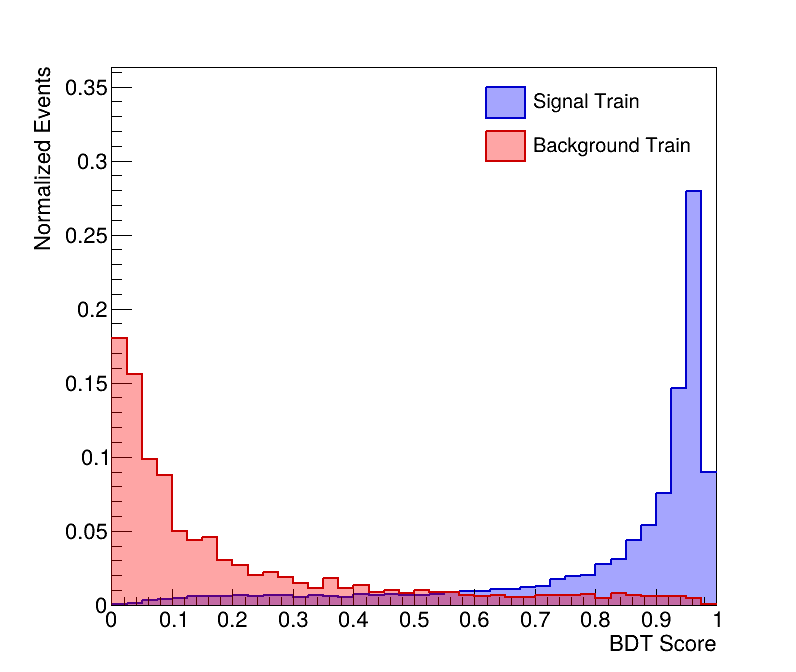

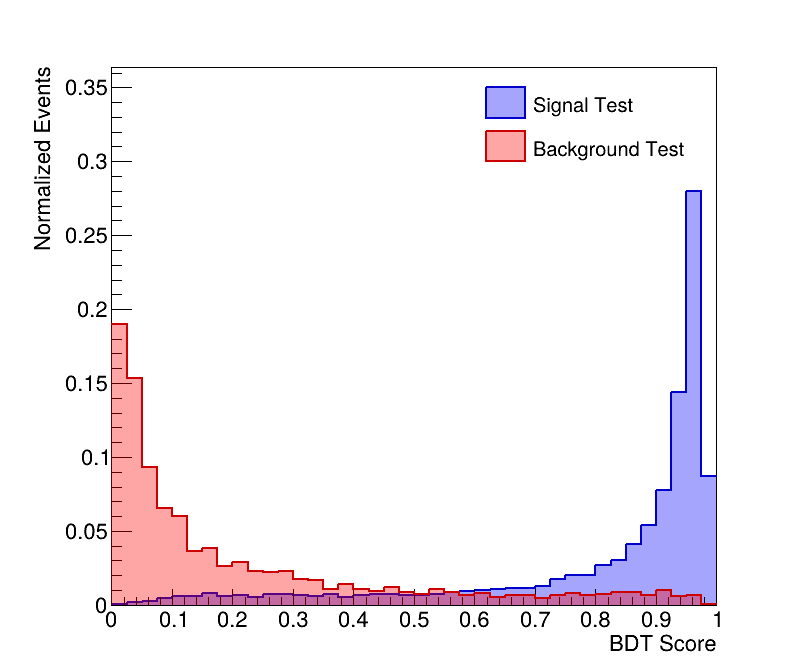

In [58]:
ROOT.gStyle.SetOptStat(0)

# -----------------------------
# Open files
# -----------------------------
f_sig_train = ROOT.TFile.Open("BDT2024MC_trees_sig_train.root")
f_sig_test  = ROOT.TFile.Open("BDT2024MC_trees_sig_test.root")

f_bkg_train = ROOT.TFile.Open("BDT2024MC_trees_bkg_train.root")
f_bkg_test  = ROOT.TFile.Open("BDT2024MC_trees_bkg_test.root")

# Trees
t_sig_train = f_sig_train.Get("Tree")
t_sig_test  = f_sig_test.Get("Tree")

t_bkg_train = f_bkg_train.Get("Tree")
t_bkg_test  = f_bkg_test.Get("Tree")

# -----------------------------
# Histograms
# -----------------------------
nbins = 40
xmin  = 0.0
xmax  = 1.0

# TRAIN
h_sig_train = ROOT.TH1F("h_sig_train", "", nbins, xmin, xmax)
h_bkg_train = ROOT.TH1F("h_bkg_train", "", nbins, xmin, xmax)

# TEST
h_sig_test = ROOT.TH1F("h_sig_test", "", nbins, xmin, xmax)
h_bkg_test = ROOT.TH1F("h_bkg_test", "", nbins, xmin, xmax)

# Fill
t_sig_train.Draw("BDT>>h_sig_train", "", "goff")
t_bkg_train.Draw("BDT>>h_bkg_train", "", "goff")

t_sig_test.Draw("BDT>>h_sig_test", "", "goff")
t_bkg_test.Draw("BDT>>h_bkg_test", "", "goff")

# Normalize
for h in [h_sig_train, h_bkg_train,
          h_sig_test, h_bkg_test]:

    if h.Integral() > 0:
        h.Scale(1.0 / h.Integral())

# -----------------------------
# Style
# -----------------------------

# Signal
h_sig_train.SetLineColor(ROOT.kBlue+1)
h_sig_train.SetFillColorAlpha(ROOT.kBlue, 0.35)
h_sig_train.SetLineWidth(2)

h_sig_test.SetLineColor(ROOT.kBlue+1)
h_sig_test.SetFillColorAlpha(ROOT.kBlue, 0.35)
h_sig_test.SetLineWidth(2)

# Background
h_bkg_train.SetLineColor(ROOT.kRed+1)
h_bkg_train.SetFillColorAlpha(ROOT.kRed, 0.35)
h_bkg_train.SetLineWidth(2)

h_bkg_test.SetLineColor(ROOT.kRed+1)
h_bkg_test.SetFillColorAlpha(ROOT.kRed, 0.35)
h_bkg_test.SetLineWidth(2)

# =============================
# TRAIN PLOT
# =============================

c_train = ROOT.TCanvas("c_train", "", 800, 700)
c_train.SetLeftMargin(0.14)

maxy_train = max(
    h_sig_train.GetMaximum(),
    h_bkg_train.GetMaximum()
)

h_sig_train.SetMaximum(maxy_train * 1.3)

h_sig_train.GetXaxis().SetTitle("BDT Score")
h_sig_train.GetYaxis().SetTitle("Normalized Events")

h_sig_train.Draw("HIST")
h_bkg_train.Draw("HIST SAME")

leg1 = ROOT.TLegend(0.60, 0.75, 0.88, 0.88)
leg1.AddEntry(h_sig_train, "Signal Train", "f")
leg1.AddEntry(h_bkg_train, "Background Train", "f")
leg1.SetBorderSize(0)
leg1.Draw()

c_train.SaveAs(Plot_dir + "BDT_train.png")
c_train.SaveAs(Plot_dir + "BDT_train.pdf")

# =============================
# TEST PLOT
# =============================

c_test = ROOT.TCanvas("c_test", "", 800, 700)
c_test.SetLeftMargin(0.14)

maxy_test = max(
    h_sig_test.GetMaximum(),
    h_bkg_test.GetMaximum()
)

h_sig_test.SetMaximum(maxy_test * 1.3)

h_sig_test.GetXaxis().SetTitle("BDT Score")
h_sig_test.GetYaxis().SetTitle("Normalized Events")

h_sig_test.Draw("HIST")
h_bkg_test.Draw("HIST SAME")

leg2 = ROOT.TLegend(0.60, 0.75, 0.88, 0.88)
leg2.AddEntry(h_sig_test, "Signal Test", "f")
leg2.AddEntry(h_bkg_test, "Background Test", "f")
leg2.SetBorderSize(0)
leg2.Draw()

c_test.SaveAs(Plot_dir + "BDT_test.png")
c_test.SaveAs(Plot_dir + "BDT_test.pdf")